# EDA — H&M Personalized Fashion Recommendations

In [2]:
import pandas as pd

customers = pd.read_csv('../data/raw/customers.csv')
articles = pd.read_csv('../data/raw/articles.csv')
transactions_sample = pd.read_csv('../data/raw/transactions_train.csv', nrows=1_000_000)

print(customers.shape)
print(articles.shape)
print(transactions_sample.shape)

(1371980, 7)
(105542, 25)
(1000000, 5)


In [3]:
print(customers.columns.tolist())
customers.head()

['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [4]:
print(articles.columns.tolist())
articles.head()

['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [5]:
print(transactions_sample.columns.tolist())
transactions_sample.head()

['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [6]:
print(transactions_sample.columns.tolist())

['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']


In [7]:
print(articles.columns.tolist())

['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']


## Data Dictionary

### customers.csv (1,371,980 rows x 7 columns)
- `customer_id`: anonymized, hashed unique identifier for each customer
- `FN`: binary flag (1.0 or missing) — appears tied to fashion news subscription; exact meaning of missing vs. 0 not yet confirmed
- `Active`: binary flag (1.0 or missing) — appears tied to active club/marketing status; same caveat as FN
- `club_member_status`: categorical membership status (e.g. "ACTIVE")
- `fashion_news_frequency`: categorical, how often the customer receives fashion news (e.g. "NONE", "Regularly")
- `age`: customer age in years
- `postal_code`: anonymized, hashed postal code

### articles.csv (105,542 rows x 25 columns)
- `article_id`: unique identifier per article variant (a specific colorway of a product)
- `product_code`: groups all colorway variants of the same base product
- `prod_name`: product name (text)
- `product_type_no` / `product_type_name`: code and name for garment type (e.g. "Vest top", "Bra")
- `product_group_name`: broader product category (e.g. "Garment Upper body", "Underwear")
- `graphical_appearance_no` / `graphical_appearance_name`: code and name for pattern/appearance (e.g. "Solid", "Stripe")
- `colour_group_code` / `colour_group_name`: code and name for the specific colour
- `perceived_colour_value_id` / `perceived_colour_value_name`: code and name for perceived colour tone
- `perceived_colour_master_id` / `perceived_colour_master_name`: code and name for master colour category
- `department_no` / `department_name`: internal department classification
- `index_code` / `index_name`: top-level index (e.g. "Ladieswear")
- `index_group_no` / `index_group_name`: broader grouping of indexes
- `section_no` / `section_name`: merchandising section
- `garment_group_no` / `garment_group_name`: garment grouping
- `detail_desc`: free-text article description

### transactions_train.csv (sample shown: 1,000,000 rows; full file ~30M rows x 5 columns)
- `t_dat`: transaction date
- `customer_id`: hashed customer identifier, foreign key to `customers.csv`
- `article_id`: article identifier, foreign key to `articles.csv`
- `price`: transaction price — appears normalized/scaled rather than raw currency (values like 0.05), exact unit/currency not yet confirmed
- `sales_channel_id`: numeric code for sales channel (e.g. store vs. online)

In [8]:
dtype_map = {
    'customer_id': 'category',
    'article_id': 'int32',
    'price': 'float32',
    'sales_channel_id': 'int8',
}

def load_transactions(path):
    return pd.read_csv(path, dtype=dtype_map, parse_dates=['t_dat'])

In [9]:
transactions = load_transactions('../data/raw/transactions_train.csv')
transactions.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 31788324 entries, 0 to 31788323
Data columns (total 5 columns):
 #   Column            Dtype         
---  ------            -----         
 0   t_dat             datetime64[us]
 1   customer_id       category      
 2   article_id        int32         
 3   price             float32       
 4   sales_channel_id  int8          
dtypes: category(1), datetime64[us](1), float32(1), int32(1), int8(1)
memory usage: 762.4 MB


In [10]:
   transactions.to_parquet('../data/raw/transactions_train.parquet')

In [11]:
import os
os.path.getsize('../data/raw/transactions_train.parquet')

2787344207

In [12]:
check = pd.read_parquet('../data/raw/transactions_train.parquet')
check.dtypes

t_dat               datetime64[us]
customer_id               category
article_id                   int32
price                      float32
sales_channel_id              int8
dtype: object

In [13]:
transactions = pd.read_parquet('../data/raw/transactions_train.parquet')
purchase_counts = transactions.groupby('customer_id').size()
purchase_counts.describe()

count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
dtype: float64

In [14]:
purchase_counts_full = customers['customer_id'].map(purchase_counts).fillna(0)
purchase_counts_full.describe()

count    1.371980e+06
mean     2.316967e+01
std      3.915214e+01
min      0.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
Name: customer_id, dtype: float64

In [15]:
cold_start_ratio = (purchase_counts_full < 3).mean() * 100
repeat_purchase_rate = (purchase_counts_full > 1).mean() * 100

print(f"Cold-start ratio (<3 purchases): {cold_start_ratio:.2f}%")
print(f"Repeat-purchase rate (>1 purchase): {repeat_purchase_rate:.2f}%")

Cold-start ratio (<3 purchases): 19.58%
Repeat-purchase rate (>1 purchase): 89.71%


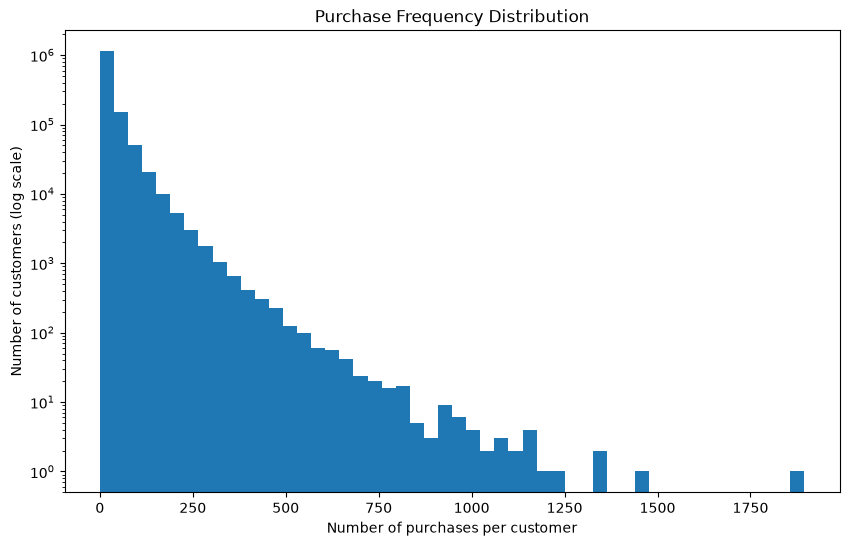

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(purchase_counts_full, bins=50)
plt.yscale('log')
plt.xlabel('Number of purchases per customer')
plt.ylabel('Number of customers (log scale)')
plt.title('Purchase Frequency Distribution')
plt.show()


In [17]:
transactions_cat = transactions.merge(
    articles[['article_id', 'product_group_name', 'department_name']],
    on='article_id',
    how='left'
)
category_counts = transactions_cat['product_group_name'].value_counts()
category_counts

product_group_name
Garment Upper body       12552755
Garment Lower body        7046054
Garment Full body         3552470
Swimwear                  2579222
Underwear                 2565858
Accessories               1599593
Shoes                      745521
Socks & Tights             685712
Nightwear                  348180
Unknown                     97040
Bags                         7313
Items                        5427
Cosmetic                     1500
Underwear/nightwear           559
Furniture                     533
Garment and Shoe care         279
Stationery                    229
Interior textile               74
Fun                             5
Name: count, dtype: int64

In [ ]:
article_purchase_counts = transactions.groupby('article_id').size()
article_purchase_counts_full = articles['article_id'].map(article_purchase_counts).fillna(0)

zero_or_one_count = (article_purchase_counts_full <= 1).sum()
zero_or_one_pct = (article_purchase_counts_full <= 1).mean() * 100

print(f"Articles with 0-1 purchases: {zero_or_one_count} ({zero_or_one_pct:.2f}%)")

## Findings

### Finding 1: Cold-start is core to the design, not an edge case
19.58% of customers have fewer than 3 purchases, and 0.71% (9,699 of 1,371,980) have made zero purchases at all — meaning any recommendation system built on this data must serve a meaningful fraction of users with little to no interaction history. This isn't a rare edge case to patch in later; it directly shapes the architecture (popularity-baseline fallback, explicit cold-start handling in the serving layer).

### Finding 2: Severe category imbalance concentrates around a few dominant groups
The top 3 product categories out of 19 (`Garment Upper body`, `Garment Lower body`, `Garment Full body`) account for 72.83% of all 31,788,324 transactions, while the bottom 9 categories combined represent under 1%. On the item side, this imbalance mirrors the user-side cold-start problem: 5,486 articles (5.20% of the catalog) have zero or one purchase — items with almost no interaction data of their own. A naive popularity-based baseline will be dominated by upper-body garments, and item-level cold-start (new or rarely-purchased articles) needs the same deliberate handling as user-level cold-start.